# Day 18 Tutorial：Batch、Epoch 与训练循环

## Goal

用 `MLPRegressor.partial_fit()` 写显式小批训练循环，证明每个 epoch 遍历全部训练行、验证行从不更新模型，并保存每轮训练/验证 RMSE。


## Setup

使用固定人工回归数据和固定 train/validation 划分。训练特征拟合 `StandardScaler`，验证特征只做 `transform`。


In [1]:
import math
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

DATA_SEED = 42
SPLIT_SEED = 17
ORDER_SEED = 42
MODEL_SEED = 42
BATCH_SIZE = 16
N_EPOCHS = 30

print({"python": platform.python_version(), "sklearn": sklearn.__version__})


{'python': '3.10.20', 'sklearn': '1.7.2'}


## Steps

### 1. 固定数据边界并仅在训练区拟合缩放器


In [2]:
rng_data = np.random.default_rng(DATA_SEED)
X = rng_data.normal(size=(120, 6))
y = (
    1.5 * X[:, 0]
    - 2.0 * X[:, 1]
    + 0.8 * X[:, 2] ** 2
    + np.sin(X[:, 3])
    + rng_data.normal(0.0, 0.2, size=len(X))
)
all_ids = np.arange(len(X))
X_train, X_valid, y_train, y_valid, train_ids, valid_ids = train_test_split(
    X, y, all_ids, test_size=0.2, random_state=SPLIT_SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
print({"train": X_train_scaled.shape, "validation": X_valid_scaled.shape})


{'train': (96, 6), 'validation': (24, 6)}


### 2. 循环外创建模型与顺序 RNG


In [3]:
order_rng = np.random.default_rng(ORDER_SEED)
model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=0.01,
    momentum=0.9,
    alpha=0.0001,
    shuffle=False,  # 外层循环已经明确打乱训练行
    random_state=MODEL_SEED,
)

expected_batches_per_epoch = math.ceil(len(X_train_scaled) / BATCH_SIZE)
print({"batch_size": BATCH_SIZE, "batches_per_epoch": expected_batches_per_epoch, "epochs": N_EPOCHS})


{'batch_size': 16, 'batches_per_epoch': 6, 'epochs': 30}


### 3. 显式 batch/epoch 训练并记录曲线


In [4]:
history_rows = []
updates_so_far = 0
all_training_ids_seen = []

for epoch in range(1, N_EPOCHS + 1):
    order = order_rng.permutation(len(X_train_scaled))
    seen_counts = np.zeros(len(X_train_scaled), dtype=int)

    for start in range(0, len(order), BATCH_SIZE):
        batch_ids = order[start:start + BATCH_SIZE]
        seen_counts[batch_ids] += 1
        all_training_ids_seen.extend(train_ids[batch_ids].tolist())
        model.partial_fit(X_train_scaled[batch_ids], y_train[batch_ids])
        updates_so_far += 1

    assert np.all(seen_counts == 1)

    train_prediction = model.predict(X_train_scaled)
    valid_prediction = model.predict(X_valid_scaled)
    history_rows.append({
        "epoch": epoch,
        "updates": updates_so_far,
        "train_rmse": float(root_mean_squared_error(y_train, train_prediction)),
        "valid_rmse": float(root_mean_squared_error(y_valid, valid_prediction)),
    })

history = pd.DataFrame(history_rows)
history["valid_minus_train_rmse"] = history["valid_rmse"] - history["train_rmse"]
display(history.head())
display(history.tail())


,epoch,updates,train_rmse,valid_rmse,valid_minus_train_rmse
0,1,6,2.264758,2.253147,-0.011611
1,2,12,1.707470,1.695920,-0.011549
2,3,18,1.384419,1.335594,-0.048825
3,4,24,1.127428,0.998483,-0.128945
4,5,30,0.948902,0.863887,-0.085015


,epoch,updates,train_rmse,valid_rmse,valid_minus_train_rmse
25,26,156,0.358388,0.464604,0.106217
26,27,162,0.354255,0.463110,0.108856
27,28,168,0.350858,0.457391,0.106533
28,29,174,0.347039,0.462846,0.115807
29,30,180,0.344348,0.467830,0.123482


### 4. 绘制实际执行曲线


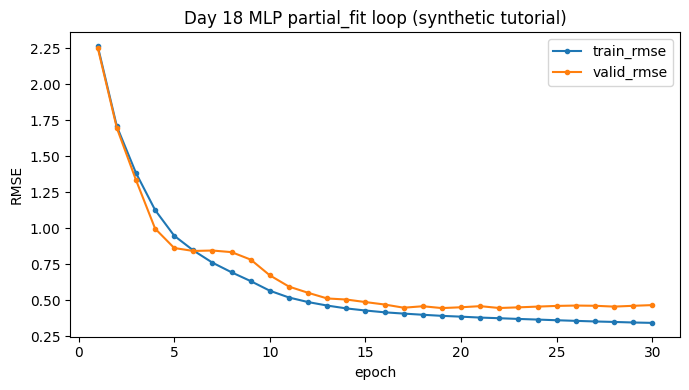

{'best_observed_validation_epoch': 19, 'best_observed_validation_rmse': 0.44705719528252585, 'note': 'descriptive only; validation participated in identifying this epoch'}


In [5]:
ax = history.plot(
    x="epoch", y=["train_rmse", "valid_rmse"], marker="o", markersize=3, figsize=(7, 4)
)
ax.set(title="Day 18 MLP partial_fit loop (synthetic tutorial)", ylabel="RMSE")
plt.tight_layout()
plt.show()

best_observed_row = history.loc[history["valid_rmse"].idxmin()]
print({
    "best_observed_validation_epoch": int(best_observed_row["epoch"]),
    "best_observed_validation_rmse": float(best_observed_row["valid_rmse"]),
    "note": "descriptive only; validation participated in identifying this epoch",
})


## Checks

验证更新次数、每轮记录、数值有效性、训练/验证 ID 隔离和缩放器状态。


In [6]:
expected_updates = N_EPOCHS * expected_batches_per_epoch
assert len(history) == N_EPOCHS
assert history["epoch"].tolist() == list(range(1, N_EPOCHS + 1))
assert updates_so_far == expected_updates
assert int(history.iloc[-1]["updates"]) == expected_updates
assert np.isfinite(history[["train_rmse", "valid_rmse"]]).all().all()
assert set(all_training_ids_seen).isdisjoint(set(valid_ids))
assert set(all_training_ids_seen) == set(train_ids)
assert np.allclose(scaler.mean_, X_train.mean(axis=0))
assert history.iloc[-1]["train_rmse"] < history.iloc[0]["train_rmse"]

print(f"Checks passed: {expected_updates} updates used training rows only; validation rows never entered partial_fit.")


Checks passed: 180 updates used training rows only; validation rows never entered partial_fit.


## Next Steps

Day 19 再把 MLP 放到 ESOL ECFP 上，Day 20 学正则化与早停。若依据验证曲线选择 epoch，必须记录该选择并保留独立评价边界；不要把本教程最佳验证 epoch 当测试结论。
